In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("FINAL_DATASET_PREDICTION_CEjour.csv")

In [3]:
df.dropna(inplace=True)

In [4]:
df.isnull().sum()

DATE            0
WELL            0
HOURS           0
WHP             0
WHT             0
W_GAS           0
WATER           0
COND_VOL        0
DELTA_DAYS      0
WHP_LAG_1       0
WHT_LAG_1       0
GAS_LAG_1       0
WATER_LAG_1     0
COND_LAG_1      0
WHP_LAG_3       0
WHT_LAG_3       0
GAS_LAG_3       0
WATER_LAG_3     0
COND_LAG_3      0
WHP_LAG_7       0
WHT_LAG_7       0
GAS_LAG_7       0
WATER_LAG_7     0
COND_LAG_7      0
GAS_MEAN_3      0
GAS_MEAN_7      0
WATER_MEAN_3    0
WATER_MEAN_7    0
COND_MEAN_3     0
COND_MEAN_7     0
DAY             0
MONTH           0
DAY_OF_WEEK     0
dtype: int64

In [5]:
# liste des puits
wellnames = df["WELL"].dropna().unique().tolist()

In [6]:
# shuffle pour randomiser
np.random.seed(42)
np.random.shuffle(wellnames)

# split
train_wells = wellnames[:80]
blind_wells = wellnames[80:89]

print("Train wells:", len(train_wells))
print("Blind wells:", len(blind_wells))

Train wells: 80
Blind wells: 9


In [7]:
# =========================
# CELL 2: TRAIN DATASET
# =========================

df_trainingwells = df[df["WELL"].isin(train_wells)].copy()

print(df_trainingwells.shape)
df_trainingwells.head()

(442244, 33)


,DATE,WELL,HOURS,WHP,WHT,W_GAS,WATER,COND_VOL,DELTA_DAYS,WHP_LAG_1,...,COND_LAG_7,GAS_MEAN_3,GAS_MEAN_7,WATER_MEAN_3,WATER_MEAN_7,COND_MEAN_3,COND_MEAN_7,DAY,MONTH,DAY_OF_WEEK
7,1999-04-09,TFT-302,24.0,100.0,56.0,0.371483,0.667162,71.568207,1.0,100.0,...,11.448846,0.371589,0.318514,0.667352,0.571406,71.588603,61.296213,9,4,4
8,1999-04-10,TFT-302,24.0,99.0,56.0,0.371391,0.662608,71.079704,1.0,100.0,...,24.612087,0.371505,0.353320,0.665739,0.633287,71.415571,67.934444,10,4,5
9,1999-04-11,TFT-302,24.0,99.0,66.0,0.371391,0.662608,71.079704,1.0,99.0,...,46.986710,0.371421,0.371534,0.664126,0.665373,71.242538,71.376300,11,4,6
10,1999-04-12,TFT-302,24.0,101.0,56.0,0.371576,0.671790,72.064720,1.0,99.0,...,71.110085,0.371453,0.371538,0.665668,0.666644,71.408043,71.512677,12,4,0
11,1999-04-13,TFT-302,24.0,102.0,57.0,0.360443,0.656057,70.377022,1.0,101.0,...,71.598801,0.367803,0.369938,0.663485,0.665017,71.173815,71.338137,13,4,1


In [8]:
# =========================
# CELL 3: FEATURES / TARGETS
# =========================

features = [
    "WHP","WHT",

    "WHP_LAG_1","WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_1","WHT_LAG_3","WHT_LAG_7",

    "GAS_LAG_1","GAS_LAG_3","GAS_LAG_7",
    "WATER_LAG_1","WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_1","COND_LAG_3","COND_LAG_7",

    "GAS_MEAN_3","GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_MEAN_3","COND_MEAN_7",

    "DAY","MONTH","DAY_OF_WEEK"
]

targets = ["W_GAS","WATER","COND_VOL"]

X = df_trainingwells[features]
y = df_trainingwells[targets]

print(X.shape)
print(y.shape)

(442244, 26)
(442244, 3)


In [9]:
# =========================
# CELL 4: CHECK DATA
# =========================

X.info()

print("\nNaN check:")
print(X.isna().sum())

<class 'pandas.DataFrame'>
Index: 442244 entries, 7 to 485773
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   WHP           442244 non-null  float64
 1   WHT           442244 non-null  float64
 2   WHP_LAG_1     442244 non-null  float64
 3   WHP_LAG_3     442244 non-null  float64
 4   WHP_LAG_7     442244 non-null  float64
 5   WHT_LAG_1     442244 non-null  float64
 6   WHT_LAG_3     442244 non-null  float64
 7   WHT_LAG_7     442244 non-null  float64
 8   GAS_LAG_1     442244 non-null  float64
 9   GAS_LAG_3     442244 non-null  float64
 10  GAS_LAG_7     442244 non-null  float64
 11  WATER_LAG_1   442244 non-null  float64
 12  WATER_LAG_3   442244 non-null  float64
 13  WATER_LAG_7   442244 non-null  float64
 14  COND_LAG_1    442244 non-null  float64
 15  COND_LAG_3    442244 non-null  float64
 16  COND_LAG_7    442244 non-null  float64
 17  GAS_MEAN_3    442244 non-null  float64
 18  GAS_MEAN_7    442244

In [10]:
# =========================
# CELL 5: TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (353795, 26)
X_test : (88449, 26)


In [11]:
# =========================
# CELL 6: QUICK CHECK
# =========================

X_train.head(5)

,WHP,WHT,WHP_LAG_1,WHP_LAG_3,WHP_LAG_7,WHT_LAG_1,WHT_LAG_3,WHT_LAG_7,GAS_LAG_1,GAS_LAG_3,...,COND_LAG_7,GAS_MEAN_3,GAS_MEAN_7,WATER_MEAN_3,WATER_MEAN_7,COND_MEAN_3,COND_MEAN_7,DAY,MONTH,DAY_OF_WEEK
444198,42.900002,60.0,42.900002,43.200001,42.099998,60.0,60.0,63.0,0.271208,0.269860,...,38.256584,0.270970,0.230628,0.242446,0.202880,35.751242,30.452767,19,10,3
471956,41.700001,55.0,41.700001,42.400002,42.400002,55.0,55.0,55.0,0.180477,0.179189,...,30.348650,0.177714,0.178603,0.190377,0.187791,29.989918,30.194044,1,12,0
394876,40.599998,47.0,40.599998,40.599998,40.599998,47.0,47.0,47.0,0.090565,0.090565,...,12.991415,0.090565,0.090565,0.000000,0.000000,12.664639,12.664639,7,4,5
140054,117.000000,48.0,117.000000,118.000000,118.000000,48.0,48.0,48.0,0.206773,0.206773,...,49.960178,0.206773,0.206773,23.111656,23.111656,49.960178,49.960178,22,2,3
18995,40.599998,48.0,40.599998,41.200001,41.200001,48.0,48.0,48.0,0.086391,0.085916,...,13.017785,0.086233,0.086052,0.030801,0.030736,13.065793,13.038360,25,1,2


In [12]:
y_train.head(5)

,W_GAS,WATER,COND_VOL
444198,0.271208,0.242660,35.782669
471956,0.173476,0.198260,29.084591
394876,0.090565,0.000000,12.664639
140054,0.206773,23.111656,49.960178
18995,0.086391,0.030858,13.089797


In [13]:
# Importing ML models
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# Importing preprocessing functionalities
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Importing metrics
from sklearn.metrics import mean_squared_error

In [14]:
# =========================
# CELL 8: PIPELINE
# =========================

pipemodel = Pipeline([
    ('scl', StandardScaler()),
    ('reg', LinearRegression())
])

In [15]:
print(X_train.isna().sum())
print(y_train.isna().sum())

WHP             0
WHT             0
WHP_LAG_1       0
WHP_LAG_3       0
WHP_LAG_7       0
WHT_LAG_1       0
WHT_LAG_3       0
WHT_LAG_7       0
GAS_LAG_1       0
GAS_LAG_3       0
GAS_LAG_7       0
WATER_LAG_1     0
WATER_LAG_3     0
WATER_LAG_7     0
COND_LAG_1      0
COND_LAG_3      0
COND_LAG_7      0
GAS_MEAN_3      0
GAS_MEAN_7      0
WATER_MEAN_3    0
WATER_MEAN_7    0
COND_MEAN_3     0
COND_MEAN_7     0
DAY             0
MONTH           0
DAY_OF_WEEK     0
dtype: int64
W_GAS       0
WATER       0
COND_VOL    0
dtype: int64


In [16]:
# =========================
# CELL 9: TRAIN
# =========================

pipemodel.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [17]:
# =========================
# CELL 10: PREDICT
# =========================

y_pred_test  = pipemodel.predict(X_test)
y_pred_train = pipemodel.predict(X_train)

print("Prediction done ✅")

Prediction done ✅


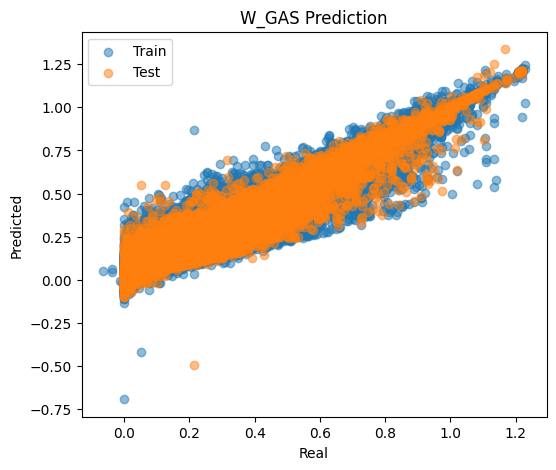

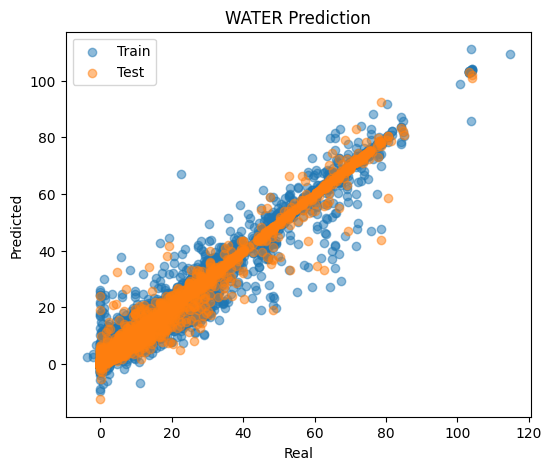

a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


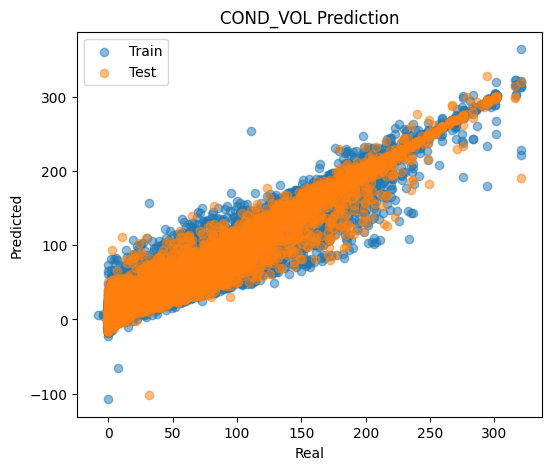

In [18]:
# =========================
# CELL 11: SCATTER PLOTS
# =========================

import matplotlib.pyplot as plt

targets = ["W_GAS","WATER","COND_VOL"]

for i, target in enumerate(targets):
    plt.figure(figsize=(6,5))
    
    plt.scatter(y_train.iloc[:, i], y_pred_train[:, i], label="Train", alpha=0.5)
    plt.scatter(y_test.iloc[:, i],  y_pred_test[:, i],  label="Test", alpha=0.5)
    
    plt.xlabel("Real")
    plt.ylabel("Predicted")
    plt.title(f"{target} Prediction")
    plt.legend()
    
    plt.show()

In [19]:
# =========================
# CELL 12: SCORES
# =========================

print("===== GLOBAL SCORES  (accuracy)=====")
print(f"Train R2: {pipemodel.score(X_train, y_train)}")
print(f"Test  R2: {pipemodel.score(X_test, y_test)}")

===== GLOBAL SCORES  (accuracy)=====
Train R2: 0.9840108894856902
Test  R2: 0.983951722518011


In [20]:
# =========================
# CELL 13: PER TARGET METRICS
# =========================

for i, target in enumerate(targets):
    
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_test[:, i])
    r2  = r2_score(y_test.iloc[:, i], y_pred_test[:, i])
    
    print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")

W_GAS -> MAE: 0.0088 | R2: 0.9785
WATER -> MAE: 0.0911 | R2: 0.9901
COND_VOL -> MAE: 1.5004 | R2: 0.9832


correlation check 

In [21]:
corr = df_trainingwells.corr(numeric_only=True)

print(corr["W_GAS"].sort_values(ascending=False).head(10))
print(corr["COND_VOL"].sort_values(ascending=False).head(10))
print(corr["WATER"].sort_values(ascending=False).head(10))

W_GAS          1.000000
GAS_MEAN_3     0.985870
GAS_MEAN_7     0.977113
GAS_LAG_1      0.968725
GAS_LAG_3      0.949161
COND_VOL       0.947054
GAS_LAG_7      0.940712
COND_MEAN_3    0.933552
COND_MEAN_7    0.925361
COND_LAG_1     0.920429
Name: W_GAS, dtype: float64
COND_VOL       1.000000
COND_MEAN_3    0.989027
COND_MEAN_7    0.982028
COND_LAG_1     0.975830
COND_LAG_3     0.960257
COND_LAG_7     0.952917
W_GAS          0.947054
GAS_MEAN_3     0.936076
GAS_MEAN_7     0.929243
GAS_LAG_1      0.920311
Name: COND_VOL, dtype: float64
WATER           1.000000
WATER_MEAN_3    0.992967
WATER_MEAN_7    0.986662
WATER_LAG_1     0.985064
WATER_LAG_3     0.971795
WATER_LAG_7     0.962966
W_GAS           0.061153
GAS_MEAN_3      0.056186
GAS_LAG_1       0.054443
HOURS           0.053975
Name: WATER, dtype: float64


In [22]:
# =========================
# CELL 14: BLIND DATA
# =========================

df_blind = df[df["WELL"].isin(blind_wells)].copy()

print("Blind shape:", df_blind.shape)
print("Number of wells:", df_blind["WELL"].nunique())

Blind shape: (42907, 33)
Number of wells: 9


In [23]:
# =========================
# CELL 15: BLIND X / y
# =========================

X_blind = df_blind[features]
y_blind = df_blind[targets]

In [24]:
# =========================
# CELL 17: PREDICT BLIND
# =========================

y_pred_blind = pipemodel.predict(X_blind)

print("Blind prediction done ✅")

Blind prediction done ✅


In [25]:
# =========================
# CELL 18: METRICS BLIND
# =========================

from sklearn.metrics import mean_absolute_error, r2_score

for i, target in enumerate(targets):
    
    mae = mean_absolute_error(y_blind.iloc[:, i], y_pred_blind[:, i])
    r2  = r2_score(y_blind.iloc[:, i], y_pred_blind[:, i])
    
    print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")

W_GAS -> MAE: 0.0072 | R2: 0.9745
WATER -> MAE: 0.2046 | R2: 0.9563
COND_VOL -> MAE: 1.2007 | R2: 0.9830


In [26]:
# =========================
# CELL 19: PER WELL
# =========================

df_blind_clean = X_blind.copy()
df_blind_clean["WELL"] = df_blind.loc[X_blind.index, "WELL"]

df_blind_clean["W_GAS"] = y_blind.iloc[:,0]
df_blind_clean["PRED_GAS"] = y_pred_blind[:,0]

result = df_blind_clean.groupby("WELL")[["W_GAS","PRED_GAS"]].mean()

print(result)

             W_GAS  PRED_GAS
WELL                        
TFT-320   0.138547  0.138615
TFT-330   0.160421  0.160837
TFT-333Z  0.286378  0.286447
TFT-361   0.346107  0.345828
TFT-370   0.138701  0.139011
TFT-386   0.311532  0.311560
TFT-391   0.165013  0.165194
TFTW-397  0.494677  0.494801
TFTW-398  0.194061  0.194846


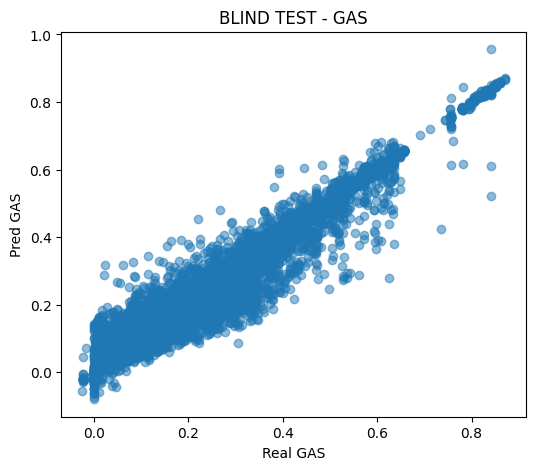

In [27]:
# =========================
# CELL 20: PLOT BLIND
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_blind.iloc[:,0], y_pred_blind[:,0], alpha=0.5)
plt.xlabel("Real GAS")
plt.ylabel("Pred GAS")
plt.title("BLIND TEST - GAS")
plt.show()

In [28]:
# =========================
# CELL: INTERACTIVE PLOT
# =========================

import matplotlib.pyplot as plt
from ipywidgets import interact

# reconstruire dataframe propre pour plot
df_plot = df_blind.copy()

# garder les mêmes index que X_blind après drop NaN
df_plot = df_plot.loc[X_blind.index].copy()

# ajouter prédictions
df_plot["PRED_W_GAS"]  = y_pred_blind[:, 0]
df_plot["PRED_WATER"]  = y_pred_blind[:, 1]
df_plot["PRED_COND"]   = y_pred_blind[:, 2]

df_plot["DATE"] = pd.to_datetime(df_plot["DATE"])

# =========================
# INTERACT FUNCTION
# =========================

def plot_wells(target="W_GAS"):

    # mapping target → prediction
    pred_map = {
        "W_GAS": "PRED_W_GAS",
        "WATER": "PRED_WATER",
        "COND_VOL": "PRED_COND"
    }

    pred_col = pred_map[target]

    wells = df_plot["WELL"].unique()

    # layout comme ton code
    fig, ax = plt.subplots(3, 2, figsize=(20, 20))
    row = [0, 0, 1, 1, 2, 2]
    col = [0, 1, 0, 1, 0, 1]

    for i, well in enumerate(wells[:6]):  # max 6 wells affichés

        dfpred = df_plot[df_plot["WELL"] == well]

        ax[row[i], col[i]].scatter(dfpred["DATE"], dfpred[target], label="Real")
        ax[row[i], col[i]].plot(dfpred["DATE"], dfpred[pred_col], color="green", label="Pred")

        ax[row[i], col[i]].set_title(well)
        ax[row[i], col[i]].tick_params(axis='x', rotation=45)
        ax[row[i], col[i]].legend()

    plt.tight_layout()
    plt.show()


# =========================
# INTERACT UI
# =========================

interact(
    plot_wells,
    target=["W_GAS", "WATER", "COND_VOL"]
);

interactive(children=(Dropdown(description='target', options=('W_GAS', 'WATER', 'COND_VOL'), value='W_GAS'), O…

In [29]:
from ipywidgets import interact, SelectMultiple

def plot_selected_wells(target="W_GAS", selected_wells=None):

    pred_map = {
        "W_GAS": "PRED_W_GAS",
        "WATER": "PRED_WATER",
        "COND_VOL": "PRED_COND"
    }

    pred_col = pred_map[target]

    wells = list(selected_wells) if selected_wells else df_plot["WELL"].unique()[:6]

    fig, ax = plt.subplots(3, 2, figsize=(20, 20))
    row = [0, 0, 1, 1, 2, 2]
    col = [0, 1, 0, 1, 0, 1]

    for i, well in enumerate(wells[:6]):

        dfpred = df_plot[df_plot["WELL"] == well]

        ax[row[i], col[i]].scatter(dfpred["DATE"], dfpred[target])
        ax[row[i], col[i]].plot(dfpred["DATE"], dfpred[pred_col], color="green")

        ax[row[i], col[i]].set_title(well)
        ax[row[i], col[i]].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


interact(
    plot_selected_wells,
    target=["W_GAS", "WATER", "COND_VOL"],
    selected_wells=SelectMultiple(options=df_plot["WELL"].unique(), value=tuple(df_plot["WELL"].unique()[:6]))
);

interactive(children=(Dropdown(description='target', options=('W_GAS', 'WATER', 'COND_VOL'), value='W_GAS'), S…

 Running Decision Trees and Random Forest

In [30]:
# =========================
# GENERIC MODEL
# =========================

def genericml(model):

    pipemodel = Pipeline([
        ('scl', StandardScaler()),
        ('reg', model)
    ])
    
    pipemodel.fit(X_train, y_train)
    
    return pipemodel

In [31]:
# =========================
# INTERACTIVE PLOTTER
# =========================

from ipywidgets import interact
import matplotlib.pyplot as plt

def plotter(model, modelname, target="W_GAS"):

    pred_map = {
        "W_GAS": 0,
        "WATER": 1,
        "COND_VOL": 2
    }

    target_idx = pred_map[target]

    # prédictions
    y_pred = model.predict(X_blind)

    df_plot = df_blind.loc[X_blind.index].copy()

    df_plot["PRED"] = y_pred[:, target_idx]

    wells = df_plot["WELL"].unique()

    fig, ax = plt.subplots(3,2, figsize=(20,20))

    row = [0, 0, 1, 1, 2, 2]
    col = [0, 1, 0, 1, 0, 1]

    for i, well in enumerate(wells[:6]):

        dfpred = df_plot[df_plot["WELL"] == well]

        ax[row[i], col[i]].scatter(dfpred["DATE"], dfpred[target], label="Real")
        ax[row[i], col[i]].plot(dfpred["DATE"], dfpred["PRED"], color="green", label=modelname)

        ax[row[i], col[i]].set_title(well)
        ax[row[i], col[i]].tick_params(axis='x', rotation=45)
        ax[row[i], col[i]].legend()

    plt.tight_layout()
    plt.show()

In [32]:
# =========================
# MODELS
# =========================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree
dtree_model = genericml(DecisionTreeRegressor())

# Random Forest
rf_model = genericml(RandomForestRegressor(
    n_estimators=30,   # 🔥 réduit
    max_depth=10,      # 🔥 limite complexité
    n_jobs=-1,         # 🔥 utilise tous les CPU
    random_state=42
))

In [33]:
# =========================
# INTERACT
# =========================

def run_plot(model_choice="RandomForest", target="W_GAS"):

    if model_choice == "DecisionTree":
        plotter(dtree_model, "DecisionTree", target)
    else:
        plotter(rf_model, "RandomForest", target)


interact(
    run_plot,
    model_choice=["DecisionTree", "RandomForest"],
    target=["W_GAS", "WATER", "COND_VOL"]
);

interactive(children=(Dropdown(description='model_choice', index=1, options=('DecisionTree', 'RandomForest'), …

ANN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

In [ ]:
ann_model = Sequential()

ann_model.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu'))
ann_model.add(Dense(64, activation='relu'))

# 🔥 3 outputs
ann_model.add(Dense(3))

optimizer = optimizers.Adam(learning_rate=0.001)

ann_model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

history = ann_model.fit(
    X_train,
    y_train.values,
    batch_size=512,
    epochs=50,   # ⚠️ pas 500 (trop long)
    verbose=1,
    validation_data=(X_test, y_test.values)
)

In [ ]:
# =========================
# ANN PREDICTION
# =========================

y_pred_ann = ann_model.predict(X_test)

In [ ]:
# =========================
# ANN METRICS
# =========================

from sklearn.metrics import mean_absolute_error, r2_score

targets = ["W_GAS","WATER","COND_VOL"]

print("===== ANN RESULTS =====")

for i, target in enumerate(targets):
    
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_ann[:, i])
    r2  = r2_score(y_test.iloc[:, i], y_pred_ann[:, i])
    
    print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")